In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import (
    RBF, Matern, WhiteKernel, ConstantKernel as C
)
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score

from mpl_toolkits.mplot3d import Axes3D
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D

In [28]:
# 폰트 설정
import matplotlib as mpl
import matplotlib.font_manager as fm

font_path = r"C:\Windows\Fonts\malgun.ttf"  
font_prop = fm.FontProperties(fname=font_path)
mpl.rcParams['font.family'] = font_prop.get_name()
mpl.rcParams['axes.unicode_minus'] = False

In [29]:
df = pd.read_excel('./datasets/swatch.xlsx')
df

,Sample,평량(g/m2),BET(m2/g),SWATCH(GD) 24h(Con),SWATCH(HD) 24h(Con)
0,ACF25-01,105.20,1150,320,280
1,ACF25-02,99.30,1450,470,220
2,ACF25-03,119.70,1150,1150,550
3,ACF25-04,110.40,1300,850,850
4,ACF25-05,103.44,1016,470,580
5,ACF25-06,122.83,1080,20,140
6,ACF25-07,154.49,1139,380,10
7,ACF25-08,140.00,1300,20,5
8,ACF25-09,130.00,2197,50,5


In [30]:
import numpy as np
import pandas as pd

df = pd.read_excel('./datasets/swatch.xlsx')

cols = df.columns
col_GD  = cols[3]
col_HD  = cols[4]
feat_names = [cols[1], cols[2]]

df['log_GD'] = np.log(df[col_GD])
df['log_HD'] = np.log(df[col_HD])

X = df[feat_names].values
y = df['log_GD'].values   # GD 먼저 수행 (HD도 동일하게 가능)

In [31]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_sc = scaler.fit_transform(X)

In [32]:
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel, WhiteKernel

# ARD: length_scale을 vector로 설정
kernel = ConstantKernel(1.0, (1e-3, 1e3)) * \
         RBF(length_scale=[1.0, 1.0], length_scale_bounds=(1e-3, 1e3)) + \
         WhiteKernel(noise_level=1e-5, noise_level_bounds=(1e-8, 1e1))

gpr = GaussianProcessRegressor(
    kernel=kernel,
    n_restarts_optimizer=20,
    random_state=42
)

gpr.fit(X_sc, y)

GaussianProcessRegressor(kernel=1**2 * RBF(length_scale=[1, 1]) + WhiteKernel(noise_level=1e-05),
                         n_restarts_optimizer=20, random_state=42)

In [33]:
# 학습된 kernel
print(gpr.kernel_)

# length-scale 추출
length_scales = gpr.kernel_.k1.k2.length_scale

for name, ls in zip(feat_names, length_scales):
    print(f"{name}: length-scale = {ls:.4f}")

5.34**2 * RBF(length_scale=[17.1, 1e+03]) + WhiteKernel(noise_level=2.35)
평량(g/m2): length-scale = 17.1261
BET(m2/g): length-scale = 1000.0000


In [34]:
importance = 1 / length_scales
importance = importance / importance.sum()

for name, imp in zip(feat_names, importance):
    print(f"{name}: importance = {imp:.3f}")

평량(g/m2): importance = 0.983
BET(m2/g): importance = 0.017


In [35]:
def run_gpr(y):
    gpr.fit(X_sc, y)
    ls = gpr.kernel_.k1.k2.length_scale
    imp = 1 / ls
    imp = imp / imp.sum()
    return ls, imp

ls_gd, imp_gd = run_gpr(df['log_GD'].values)
ls_hd, imp_hd = run_gpr(df['log_HD'].values)

print("=== GD ===")
for n, l, i in zip(feat_names, ls_gd, imp_gd):
    print(n, l, i)

print("\n=== HD ===")
for n, l, i in zip(feat_names, ls_hd, imp_hd):
    print(n, l, i)

=== GD ===
평량(g/m2) 17.12614837653985 0.9831622179767227
BET(m2/g) 999.9999999999998 0.01683778202327737

=== HD ===
평량(g/m2) 1.191800207107287 0.8574960337854348
BET(m2/g) 7.1714772423976525 0.1425039662145652


In [39]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score, mean_squared_error

def visualize_gpr_ard(gpr, X_raw, X_sc, y_log, scaler, feat_names, target_name):
    samples = df['Sample'].tolist()

    # =========================
    # 1. Predicted vs Observed
    # =========================
    y_pred_log, y_std_log = gpr.predict(X_sc, return_std=True)

    y_true = np.exp(y_log)
    y_pred = np.exp(y_pred_log)

    r2 = r2_score(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))

    plt.figure(figsize=(6, 5))
    plt.scatter(y_true, y_pred, s=60, alpha=0.8)

    lim_min = min(y_true.min(), y_pred.min())
    lim_max = max(y_true.max(), y_pred.max())
    plt.plot([lim_min, lim_max], [lim_min, lim_max], linestyle='--')

    plt.xlabel("Observed")
    plt.ylabel("Predicted")
    plt.title(f"{target_name}: Observed vs Predicted\nR2={r2:.3f}, RMSE={rmse:.3f}")
    plt.grid(alpha=0.3)
    plt.show()

    # =========================
    # 2. 3D Response Surface
    # =========================
    x1 = X_raw[:, 0]
    x2 = X_raw[:, 1]

    x1_grid = np.linspace(x1.min(), x1.max(), 60)
    x2_grid = np.linspace(x2.min(), x2.max(), 60)

    xx, yy = np.meshgrid(x1_grid, x2_grid)

    X_grid_raw = np.column_stack([xx.ravel(), yy.ravel()])
    X_grid_sc = scaler.transform(X_grid_raw)

    z_log, z_std_log = gpr.predict(X_grid_sc, return_std=True)
    z = np.exp(z_log).reshape(xx.shape)

    fig = plt.figure(figsize=(16, 7))
    ax = fig.add_subplot(111, projection='3d')

    # GPR 회귀면
    ax.plot_surface(
        xx, yy, z,
        alpha=0.30,
        color='mediumpurple',
        edgecolor='none'
    )

    ax.plot_wireframe(
        xx, yy, z,
        alpha=0.18,
        color='purple',
        linewidth=0.35
    )

    # 합/불 색상
    colors = ['limegreen' if v <= lim else 'tomato' for v in y_true]

    ax.scatter(
        x1, x2, y_true,
        c=colors,
        s=120,
        edgecolors='black',
        linewidths=0.6,
        depthshade=True
    )

    # # 기준 평면
    # xx_lim, yy_lim = np.meshgrid(
    #     np.linspace(x1.min() - 5,  x1.max() + 5,  10),
    #     np.linspace(x2.min() - 50, x2.max() + 50, 10)
    # )
    # zz_lim = np.full_like(xx_lim, lim)

    # ax.plot_surface(
    #     xx_lim, yy_lim, zz_lim,
    #     alpha=0.15,
    #     color='red'
    # )

    # 바닥 수직선
    for xi, yi, zi in zip(x1, x2, y_true):
        ax.plot(
            [xi, xi],
            [yi, yi],
            [0, zi],
            color='gray',
            linewidth=0.6,
            linestyle=':',
            alpha=0.5
        )

    # 샘플 레이블
    for i, (xi, yi, zi) in enumerate(zip(x1, x2, y_true)):
        label = df.loc[i, sample_col] if sample_col in df.columns else str(i)

        ax.text(
            xi, yi, zi + 20,
            label,
            fontsize=7,
            ha='center'
        )

    ax.set_xlabel(feat_names[0], fontsize=9, labelpad=8)
    ax.set_ylabel(feat_names[1], fontsize=9, labelpad=8)
    ax.set_zlabel(target_name, fontsize=9, labelpad=8)

    ax.set_title(
        f'{feat_names[0]} x {feat_names[1]} x {target_name}\nGPR-ARD Response Surface',
        fontsize=12,
        fontweight='bold'
    )

    leg = [
        mpatches.Patch(color='mediumpurple', alpha=0.5, label='GPR-ARD surface'),
        mpatches.Patch(color='red', alpha=0.3, label=f'기준()'),
        Line2D([0], [0], marker='o', color='w',
            markerfacecolor='limegreen', markersize=8,
            label='합격', markeredgecolor='black'),
        Line2D([0], [0], marker='o', color='w',
            markerfacecolor='tomato', markersize=8,
            label='불합격', markeredgecolor='black'),
    ]

    ax.legend(handles=leg, fontsize=7, loc='upper left')
    ax.view_init(elev=22, azim=-50)

    plt.tight_layout()
    plt.show()
    # =========================
    # 3. ARD Feature Importance
    # =========================
    length_scales = gpr.kernel_.k1.k2.length_scale

    importance = 1 / length_scales
    importance = importance / importance.sum()

    plt.figure(figsize=(6, 4))
    plt.bar(feat_names, importance)
    plt.ylabel("importance")
    plt.title(f"{target_name}\nARD Feature Importance")
    plt.ylim(0, 1)
    plt.grid(axis='y', alpha=0.3)
    plt.show()

    print(f"\n[{target_name}]")
    print("Learned kernel:")
    print(gpr.kernel_)

    print("\nARD length-scale")
    for name, ls in zip(feat_names, length_scales):
        print(f"{name}: {ls:.4f}")

    print("\nNormalized importance")
    for name, imp in zip(feat_names, importance):
        print(f"{name}: {imp:.4f}")

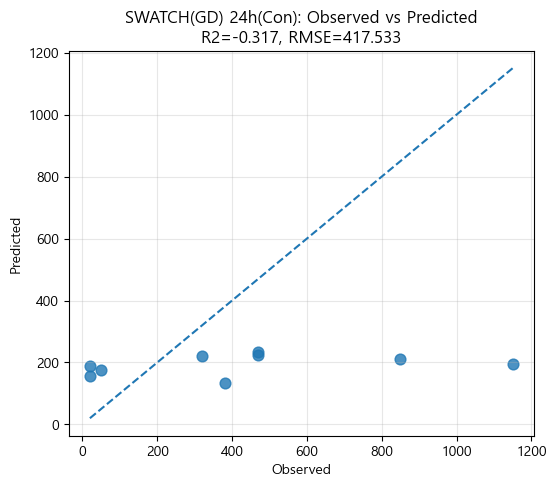

NameError: name 'lim' is not defined

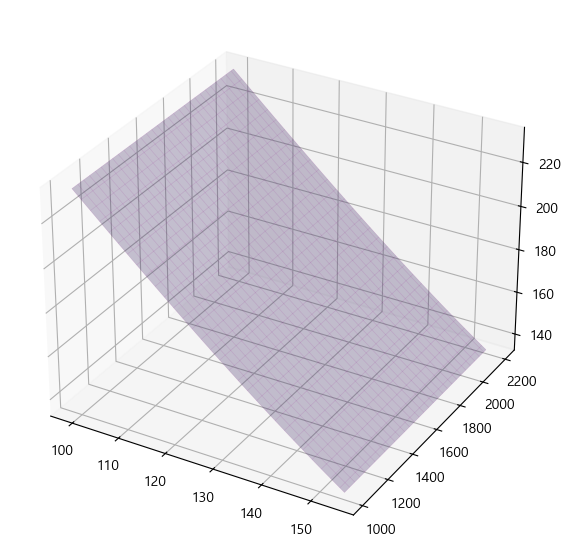

In [ ]:
y_hd = df['log_GD'].values

gpr.fit(X_sc, y_hd)

def visualize_gpr_ard(
    gpr, X_raw, X_sc, y_log, scaler,
    feat_names, target_name,
    df=None, sample_col='Sample', lim=None
)

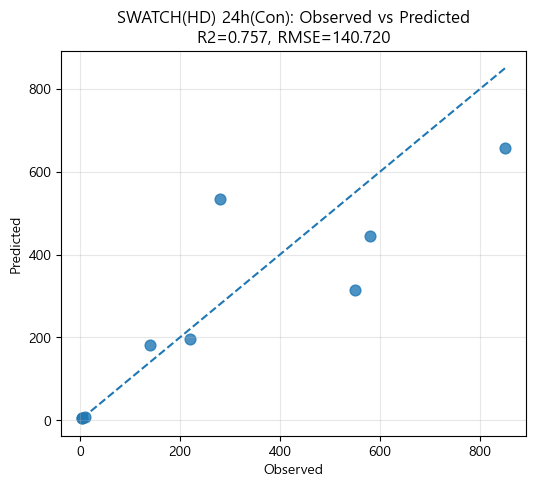

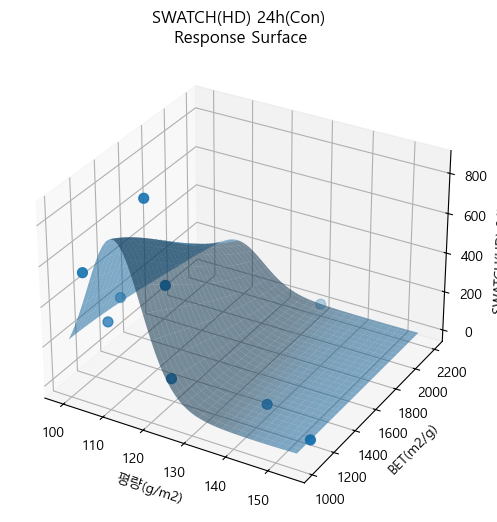

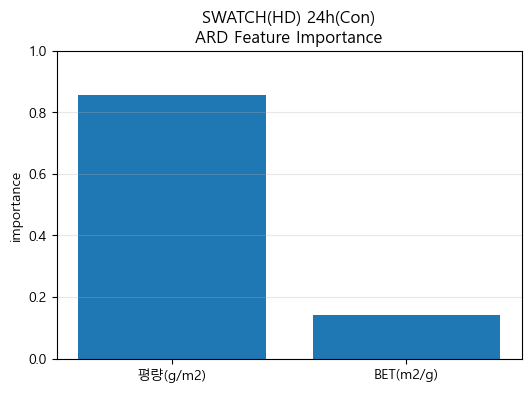


[SWATCH(HD) 24h(Con)]
Learned kernel:
3.63**2 * RBF(length_scale=[1.19, 7.17]) + WhiteKernel(noise_level=0.277)

ARD length-scale
평량(g/m2): 1.1918
BET(m2/g): 7.1715

Normalized importance
평량(g/m2): 0.8575
BET(m2/g): 0.1425


In [ ]:
y_hd = df['log_HD'].values

gpr.fit(X_sc, y_hd)

visualize_gpr_ard(
    gpr=gpr,
    X_raw=X,
    X_sc=X_sc,
    y_log=y_hd,
    scaler=scaler,
    feat_names=feat_names,
    target_name="SWATCH(HD) 24h(Con)"
)

In [ ]:
# =========================
# 2. 3D Response Surface
# =========================
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D



NameError: name 'X_raw' is not defined

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

from matplotlib.lines import Line2D
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel, WhiteKernel



In [4]:

# =========================
# 1. Data Load
# =========================
df = pd.read_excel('./datasets/swatch.xlsx')

cols = df.columns
col_GD = cols[3]   # 'SWATCH(GD) 24h(Con)'
col_HD = cols[4]   # 'SWATCH(HD) 24h(Con)'

feat_names = [cols[1], cols[2]]   # ['평량(g/m2)', 'BET(m2/g)']

df['log_GD'] = np.log(df[col_GD])
df['log_HD'] = np.log(df[col_HD])

X_raw = df[feat_names].values
X_raw

scaler = StandardScaler()
X_sc = scaler.fit_transform(X_raw)


In [5]:
# =========================
# 2. GPR-ARD Function
# =========================
def fit_gpr_ard(X_sc, y_log, random_state=42):
    kernel = (
        ConstantKernel(1.0, (1e-3, 1e3))
        * RBF(
            length_scale=np.ones(X_sc.shape[1]),
            length_scale_bounds=(1e-3, 1e3)
        )
        + WhiteKernel(
            noise_level=1e-5,
            noise_level_bounds=(1e-8, 1e1)
        )
    )

    gpr = GaussianProcessRegressor(
        kernel=kernel,
        n_restarts_optimizer=20,
        normalize_y=True,
        random_state=random_state
    )

    gpr.fit(X_sc, y_log)
    return gpr


In [6]:
# =========================
# 3. Visualization Function
# =========================
def visualize_gpr_ard(
    gpr,
    X_raw,
    X_sc,
    y_log,
    scaler,
    feat_names,
    target_name,
    df=None,
    sample_col='Sample',
    lim=None,
    label_offset=20
):
    y_pred_log, y_std_log = gpr.predict(X_sc, return_std=True)

    y_true = np.exp(y_log)
    y_pred = np.exp(y_pred_log)

    r2 = r2_score(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))

    # =========================
    # 3-1. Observed vs Predicted
    # =========================
    plt.figure(figsize=(6, 5))

    plt.scatter(
        y_true,
        y_pred,
        s=70,
        alpha=0.8,
        edgecolors='black',
        linewidths=0.5
    )

    lim_min = min(y_true.min(), y_pred.min())
    lim_max = max(y_true.max(), y_pred.max())

    plt.plot(
        [lim_min, lim_max],
        [lim_min, lim_max],
        linestyle='--',
        color='gray'
    )

    plt.xlabel("Observed")
    plt.ylabel("Fitted")
    plt.title(
        f"{target_name}\nObserved vs Fitted\n"
        f"R² = {r2:.3f}, RMSE = {rmse:.3f}"
    )
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

    # =========================
    # 3-2. 3D Response Surface
    # =========================
    x1 = X_raw[:, 0]
    x2 = X_raw[:, 1]

    x1_grid = np.linspace(x1.min(), x1.max(), 60)
    x2_grid = np.linspace(x2.min(), x2.max(), 60)

    xx, yy = np.meshgrid(x1_grid, x2_grid)

    X_grid_raw = np.column_stack([xx.ravel(), yy.ravel()])
    X_grid_sc = scaler.transform(X_grid_raw)

    z_log, z_std_log = gpr.predict(X_grid_sc, return_std=True)
    z = np.exp(z_log).reshape(xx.shape)

    fig = plt.figure(figsize=(16, 7))
    ax = fig.add_subplot(111, projection='3d')

    # GPR-ARD surface
    ax.plot_surface(
        xx,
        yy,
        z,
        alpha=0.30,
        color='mediumpurple',
        edgecolor='none'
    )

    ax.plot_wireframe(
        xx,
        yy,
        z,
        alpha=0.18,
        color='purple',
        linewidth=0.35
    )

    # pass/fail colors
    if lim is not None:
        colors = ['limegreen' if v <= lim else 'tomato' for v in y_true]
    else:
        colors = 'limegreen'

    ax.scatter(
        x1,
        x2,
        y_true,
        c=colors,
        s=120,
        edgecolors='black',
        linewidths=0.6,
        depthshade=True
    )

    # threshold plane
    if lim is not None:
        xx_lim, yy_lim = np.meshgrid(
            np.linspace(x1.min() - 5, x1.max() + 5, 10),
            np.linspace(x2.min() - 50, x2.max() + 50, 10)
        )
        zz_lim = np.full_like(xx_lim, lim)

        ax.plot_surface(
            xx_lim,
            yy_lim,
            zz_lim,
            alpha=0.15,
            color='red'
        )

    # vertical dotted lines
    for xi, yi, zi in zip(x1, x2, y_true):
        ax.plot(
            [xi, xi],
            [yi, yi],
            [0, zi],
            color='gray',
            linewidth=0.6,
            linestyle=':',
            alpha=0.5
        )

    # sample labels
    for i, (xi, yi, zi) in enumerate(zip(x1, x2, y_true)):
        if df is not None and sample_col in df.columns:
            label = str(df.iloc[i][sample_col])
        else:
            label = str(i + 1)

        ax.text(
            xi,
            yi,
            zi + label_offset,
            label,
            fontsize=7,
            ha='center'
        )

    ax.set_xlabel(feat_names[0], fontsize=9, labelpad=8)
    ax.set_ylabel(feat_names[1], fontsize=9, labelpad=8)
    ax.set_zlabel(target_name, fontsize=9, labelpad=8)

    ax.set_title(
        f'{feat_names[0]} × {feat_names[1]} × {target_name}\n'
        f'GPR-ARD Response Surface',
        fontsize=12,
        fontweight='bold'
    )

    leg = [
        mpatches.Patch(
            color='mediumpurple',
            alpha=0.5,
            label='GPR-ARD surface'
        )
    ]

    if lim is not None:
        leg.extend([
            mpatches.Patch(
                color='red',
                alpha=0.3,
                label=f'기준({lim})'
            ),
            Line2D(
                [0], [0],
                marker='o',
                color='w',
                markerfacecolor='limegreen',
                markersize=8,
                label='합격',
                markeredgecolor='black'
            ),
            Line2D(
                [0], [0],
                marker='o',
                color='w',
                markerfacecolor='tomato',
                markersize=8,
                label='불합격',
                markeredgecolor='black'
            )
        ])

    ax.legend(handles=leg, fontsize=7, loc='upper left')
    ax.view_init(elev=22, azim=-50)

    plt.tight_layout()
    plt.show()

    # =========================
    # 3-3. ARD Feature Importance
    # =========================
    length_scales = gpr.kernel_.k1.k2.length_scale

    importance = 1 / length_scales
    importance = importance / importance.sum()

    plt.figure(figsize=(6, 4))

    plt.bar(
        feat_names,
        importance,
        edgecolor='black'
    )

    plt.ylabel("Normalized importance")
    plt.title(f"{target_name}\nARD Feature Importance")
    plt.ylim(0, 1)
    plt.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.show()

    # =========================
    # 3-4. Print Result
    # =========================
    print(f"\n[{target_name}]")
    print("Learned kernel:")
    print(gpr.kernel_)

    print("\nARD length-scale")
    for name, ls in zip(feat_names, length_scales):
        print(f"{name}: {ls:.4f}")

    print("\nNormalized importance")
    for name, imp in zip(feat_names, importance):
        print(f"{name}: {imp:.4f}")

    print(f"\nR²: {r2:.4f}")
    print(f"RMSE: {rmse:.4f}")

    return {
        "gpr": gpr,
        "length_scales": length_scales,
        "importance": importance,
        "r2": r2,
        "rmse": rmse
    }




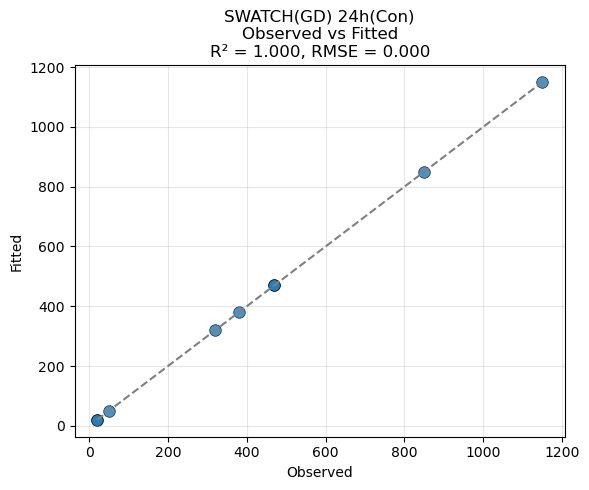

C:\Users\user\AppData\Local\Temp\ipykernel_33640\181918827.py:208: UserWarning: Glyph 54217 (\N{HANGUL SYLLABLE PYEONG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\user\AppData\Local\Temp\ipykernel_33640\181918827.py:208: UserWarning: Glyph 47049 (\N{HANGUL SYLLABLE RYANG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\user\AppData\Local\Temp\ipykernel_33640\181918827.py:208: UserWarning: Glyph 44592 (\N{HANGUL SYLLABLE GI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\user\AppData\Local\Temp\ipykernel_33640\181918827.py:208: UserWarning: Glyph 51456 (\N{HANGUL SYLLABLE JUN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\user\AppData\Local\Temp\ipykernel_33640\181918827.py:208: UserWarning: Glyph 54633 (\N{HANGUL SYLLABLE HAB}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\user\AppData\Local\Temp\ipykernel_33640\181918827.py:208: UserWarning: Glyph 44201 (\N{HANGUL SYLLABLE GYEOG}) missing fro

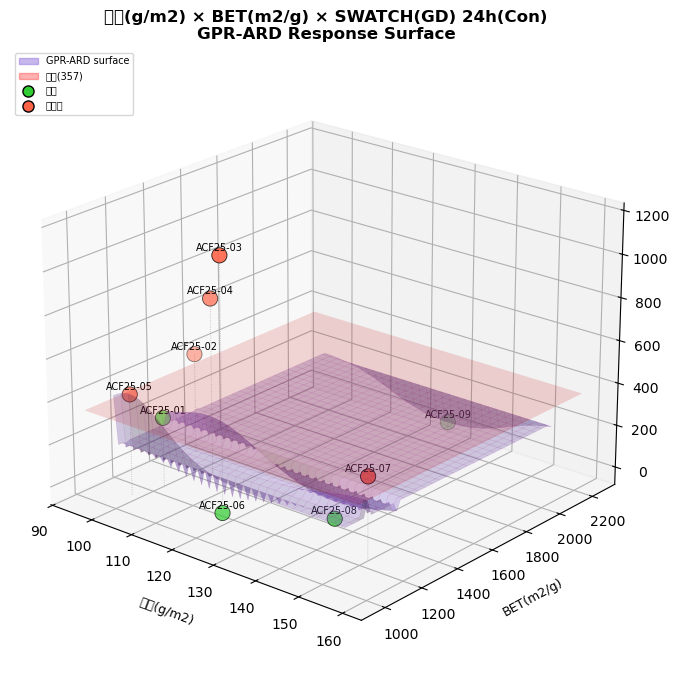

C:\Users\user\AppData\Local\Temp\ipykernel_33640\181918827.py:231: UserWarning: Glyph 54217 (\N{HANGUL SYLLABLE PYEONG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\user\AppData\Local\Temp\ipykernel_33640\181918827.py:231: UserWarning: Glyph 47049 (\N{HANGUL SYLLABLE RYANG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()


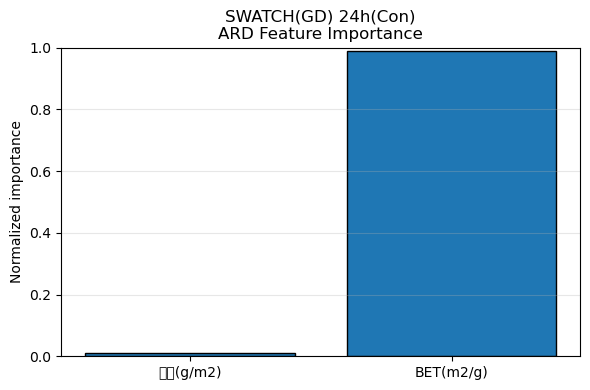


[SWATCH(GD) 24h(Con)]
Learned kernel:
0.998**2 * RBF(length_scale=[0.586, 0.00702]) + WhiteKernel(noise_level=3.08e-07)

ARD length-scale
평량(g/m2): 0.5861
BET(m2/g): 0.0070

Normalized importance
평량(g/m2): 0.0118
BET(m2/g): 0.9882

R²: 1.0000
RMSE: 0.0003


In [7]:
# =========================
# 4. Run GD
# =========================
y_gd_log = df['log_GD'].values

gpr_gd = fit_gpr_ard(X_sc, y_gd_log)

res_gd = visualize_gpr_ard(
    gpr=gpr_gd,
    X_raw=X_raw,
    X_sc=X_sc,
    y_log=y_gd_log,
    scaler=scaler,
    feat_names=feat_names,
    target_name=col_GD,
    df=df,
    sample_col='Sample',
    lim=357,              # 필요에 맞게 수정
    label_offset=20
)


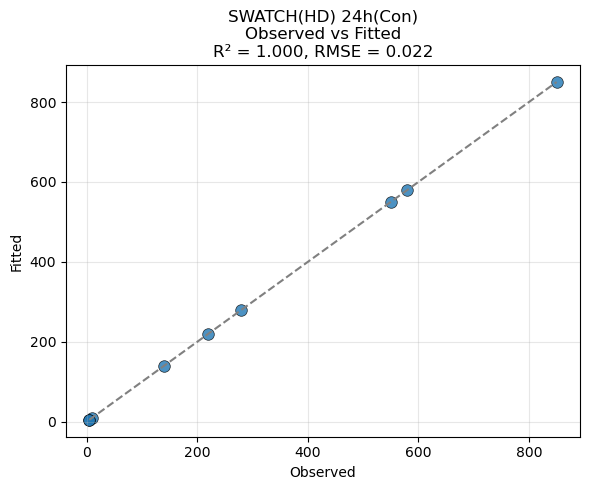

C:\Users\user\AppData\Local\Temp\ipykernel_33640\181918827.py:208: UserWarning: Glyph 54217 (\N{HANGUL SYLLABLE PYEONG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\user\AppData\Local\Temp\ipykernel_33640\181918827.py:208: UserWarning: Glyph 47049 (\N{HANGUL SYLLABLE RYANG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\user\AppData\Local\Temp\ipykernel_33640\181918827.py:208: UserWarning: Glyph 44592 (\N{HANGUL SYLLABLE GI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\user\AppData\Local\Temp\ipykernel_33640\181918827.py:208: UserWarning: Glyph 51456 (\N{HANGUL SYLLABLE JUN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\user\AppData\Local\Temp\ipykernel_33640\181918827.py:208: UserWarning: Glyph 54633 (\N{HANGUL SYLLABLE HAB}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\user\AppData\Local\Temp\ipykernel_33640\181918827.py:208: UserWarning: Glyph 44201 (\N{HANGUL SYLLABLE GYEOG}) missing fro

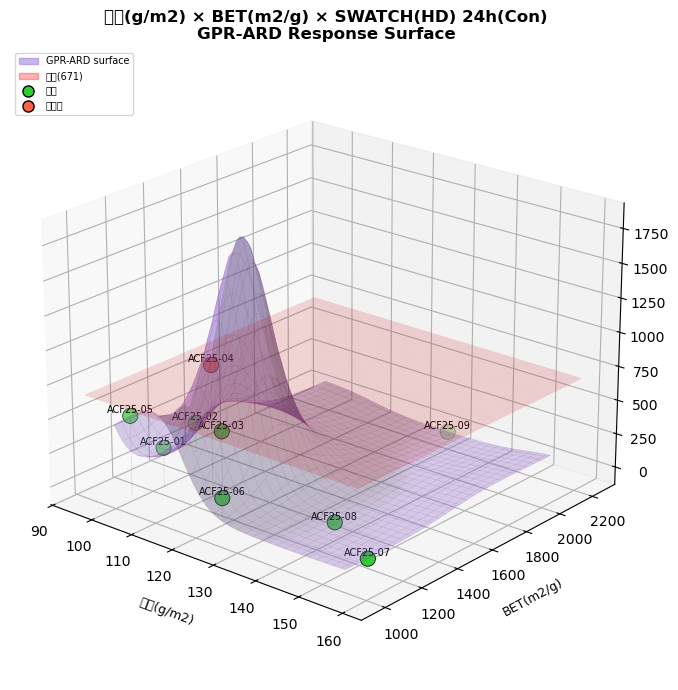

C:\Users\user\AppData\Local\Temp\ipykernel_33640\181918827.py:231: UserWarning: Glyph 54217 (\N{HANGUL SYLLABLE PYEONG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\user\AppData\Local\Temp\ipykernel_33640\181918827.py:231: UserWarning: Glyph 47049 (\N{HANGUL SYLLABLE RYANG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()


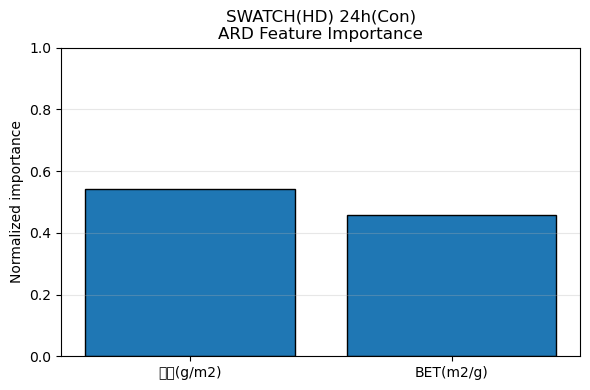


[SWATCH(HD) 24h(Con)]
Learned kernel:
1.11**2 * RBF(length_scale=[0.608, 0.722]) + WhiteKernel(noise_level=1e-05)

ARD length-scale
평량(g/m2): 0.6083
BET(m2/g): 0.7217

Normalized importance
평량(g/m2): 0.5426
BET(m2/g): 0.4574

R²: 1.0000
RMSE: 0.0219


In [8]:
# =========================
# 5. Run HD
# =========================
y_hd_log = df['log_HD'].values

gpr_hd = fit_gpr_ard(X_sc, y_hd_log)

res_hd = visualize_gpr_ard(
    gpr=gpr_hd,
    X_raw=X_raw,
    X_sc=X_sc,
    y_log=y_hd_log,
    scaler=scaler,
    feat_names=feat_names,
    target_name=col_HD,
    df=df,
    sample_col='Sample',
    lim=671,              # 필요에 맞게 수정
    label_offset=20
)